# **Experiment Details**

**Name:** Krish Sodhi

**UID:** 2023300233

**Batch:** D

**Experiment no.:** 3

**Title of the Experiment:** Application of Transfer Learning using Pre-trained CNN Models

## **Objective**

To design, implement, and evaluate an image classification system using Transfer Learning with pre-trained Convolutional Neural Network (CNN) models in Python


## **Theory**

### **1. Transfer Learning**

Transfer Learning is a deep learning technique in which a model trained on a large and general dataset is reused for a different but related task. Instead of initializing model parameters randomly, the knowledge learned from a source task is transferred to a target task.

Mathematically, if:

* ( D_s ) → Source dataset
* ( D_t ) → Target dataset
* ( T_s ) → Source task
* ( T_t ) → Target task

Transfer learning improves learning of ( T_t ) in ( D_t ) using knowledge from ( D_s ) and ( T_s ).

This approach is highly effective when the target dataset is small.


### **2. Pre-trained Models**

A pre-trained model is a model that has already been trained on a large-scale dataset and has learned generalized feature representations. Most commonly, these models are trained on:

* ImageNet

ImageNet contains millions of labeled images across thousands of categories. Models trained on this dataset learn rich and transferable feature representations.

Deep learning libraries that provide ready-to-use pre-trained models include:

* TensorFlow
* Keras


### 3. Working Principle of Transfer Learning

Transfer learning works by:

1. Loading a model pre-trained on a large dataset.
2. Removing the final task-specific classification layer.
3. Adding new layers suitable for the target dataset.
4. Training only the new layers or selectively retraining some earlier layers.

The previously learned weights act as a strong initialization, enabling faster convergence and improved generalization.


### 4. Feature Extraction

In feature extraction:

* The pre-trained layers are frozen.
* Their parameters are not updated during training.
* Only newly added layers are trained.

Advantages:

* Reduced training time
* Lower computational cost
* Less risk of overfitting

This method is ideal when the dataset size is small.


### 5. Fine-Tuning

Fine-tuning involves:

* Unfreezing some of the pre-trained layers.
* Updating their weights along with the new layers.
* Using a small learning rate to preserve previously learned knowledge.

Fine-tuning improves performance when the new dataset is sufficiently large and similar to the original dataset.


### 6. Role of Freezing Layers

Freezing layers means preventing their weights from being updated during backpropagation.

Purpose:

* Retain generalized learned features
* Avoid overfitting
* Reduce computational complexity

Only trainable layers receive gradient updates.


### 7. Advantages of Transfer Learning

* Requires less training data
* Faster model convergence
* Reduced computational cost
* Better performance compared to training from scratch
* Practical for real-world applications

### 8. Challenges in Transfer Learning

* Domain mismatch between source and target dataset
* Negative transfer (performance degradation)
* Overfitting during fine-tuning
* Hyperparameter sensitivity

Careful selection of trainable layers and learning rate is necessary.




## **Pre-Lab Questions :-**

**1. What is Transfer Learning, and why is it useful in deep learning?**

Transfer Learning is a deep learning technique in which a model trained on a large dataset for one task is reused and adapted 
for another related task. Instead of initializing model parameters randomly, the learned weights from the source task are 
transferred to the target task. This approach is useful because it significantly reduces training time, requires less labeled 
data, improves convergence speed, and often achieves better performance compared to training a model from scratch, especially 
when the target dataset is small.

**2. What are pre-trained models, and on which dataset are they commonly trained?**


Pre-trained models are models that have already been trained on large-scale datasets and have learned generalized feature 
representations. These models are commonly trained on ImageNet, which contains millions of labeled images across thousands of 
categories. Because of the size and diversity of this dataset, the learned representations are highly transferable to other 
image classification tasks.

**3. What is the difference between feature extraction and fine-tuning in transfer learning?**


Feature extraction involves using a pre-trained model as a fixed feature extractor by freezing its learned layers and training 
only the newly added layers for the target task. In contrast, fine-tuning involves unfreezing some of the pre-trained layers 
and allowing their weights to be updated during training. Feature extraction is computationally efficient and suitable for 
small datasets, whereas fine-tuning allows better adaptation to the new dataset but requires careful selection of learning 
rate and trainable layers.

**4. Why are models trained on ImageNet effective for many vision tasks?**


Models trained on ImageNet are effective for many vision tasks because the dataset is large and diverse, containing millions 
of images from numerous object categories. Training on such a comprehensive dataset enables the model to learn generalized and 
transferable visual representations, which can be successfully applied to various other classification problems.



**5. What is the role of freezing layers in a pre-trained model?**

Freezing layers in a pre-trained model means preventing their weights from being updated during backpropagation. This helps 
preserve the previously learned generalized knowledge while reducing computational cost and training time. Freezing layers 
also minimizes the risk of overfitting, especially when the new dataset is small, since fewer parameters are adjusted during 
training.

**6. How does transfer learning help when the dataset size is small?**

When the dataset size is small, training a model from scratch can lead to overfitting and poor generalization. Transfer 
learning addresses this issue by leveraging previously learned representations from a large dataset. Since many useful 
features are already learned, only a limited number of parameters need to be trained, which improves generalization 
performance and allows the model to achieve high accuracy even with limited data.

**7. What challenges may arise while applying transfer learning to a new dataset?**

Several challenges may arise when applying transfer learning, including domain mismatch between the source and target 
datasets, which may reduce performance. Negative transfer can occur if the tasks are not sufficiently related. Overfitting may 
happen when too many layers are fine-tuned on a small dataset. Additionally, improper selection of learning rate and 
hyperparameters can negatively affect model performance. Careful experimentation and tuning are therefore required to achieve 
optimal results.

## **1. Download Dataset :-**
I have picked a dataset for food type classification

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("l33tc0d3r/indian-food-classification")

print("Path to dataset files:", path)

c:\Users\ASUS\anaconda3\envs\yoloenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\l33tc0d3r\indian-food-classification\versions\1


In [5]:
import os
print(os.listdir(path+"/Food Classification"))

['burger', 'butter_naan', 'chai', 'chapati', 'chole_bhature', 'dal_makhani', 'dhokla', 'fried_rice', 'idli', 'jalebi', 'kaathi_rolls', 'kadai_paneer', 'kulfi', 'masala_dosa', 'momos', 'paani_puri', 'pakode', 'pav_bhaji', 'pizza', 'samosa']


## **2. Analyse the data :-**

### **Test for class imbabalance**

burger: 309 images
butter_naan: 329 images
chai: 381 images
chapati: 413 images
chole_bhature: 411 images
dal_makhani: 321 images
dhokla: 289 images
fried_rice: 355 images
idli: 310 images
jalebi: 297 images
kaathi_rolls: 293 images
kadai_paneer: 412 images
kulfi: 237 images
masala_dosa: 311 images
momos: 319 images
paani_puri: 130 images
pakode: 278 images
pav_bhaji: 353 images
pizza: 261 images
samosa: 262 images


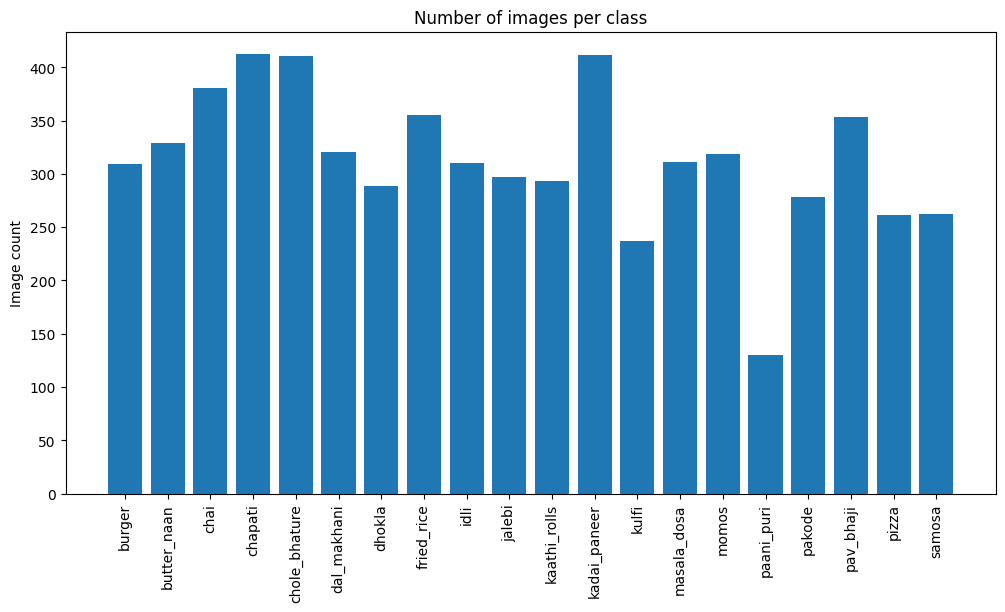

In [6]:
import os
import matplotlib.pyplot as plt

dataset_path = path + "/Food Classification"
classes = os.listdir(dataset_path)

class_counts = {}
for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    class_counts[cls] = len(os.listdir(class_path))

# Display counts
for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

# Plot bar chart
plt.figure(figsize=(12,6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Number of images per class")
plt.ylabel("Image count")
plt.show()


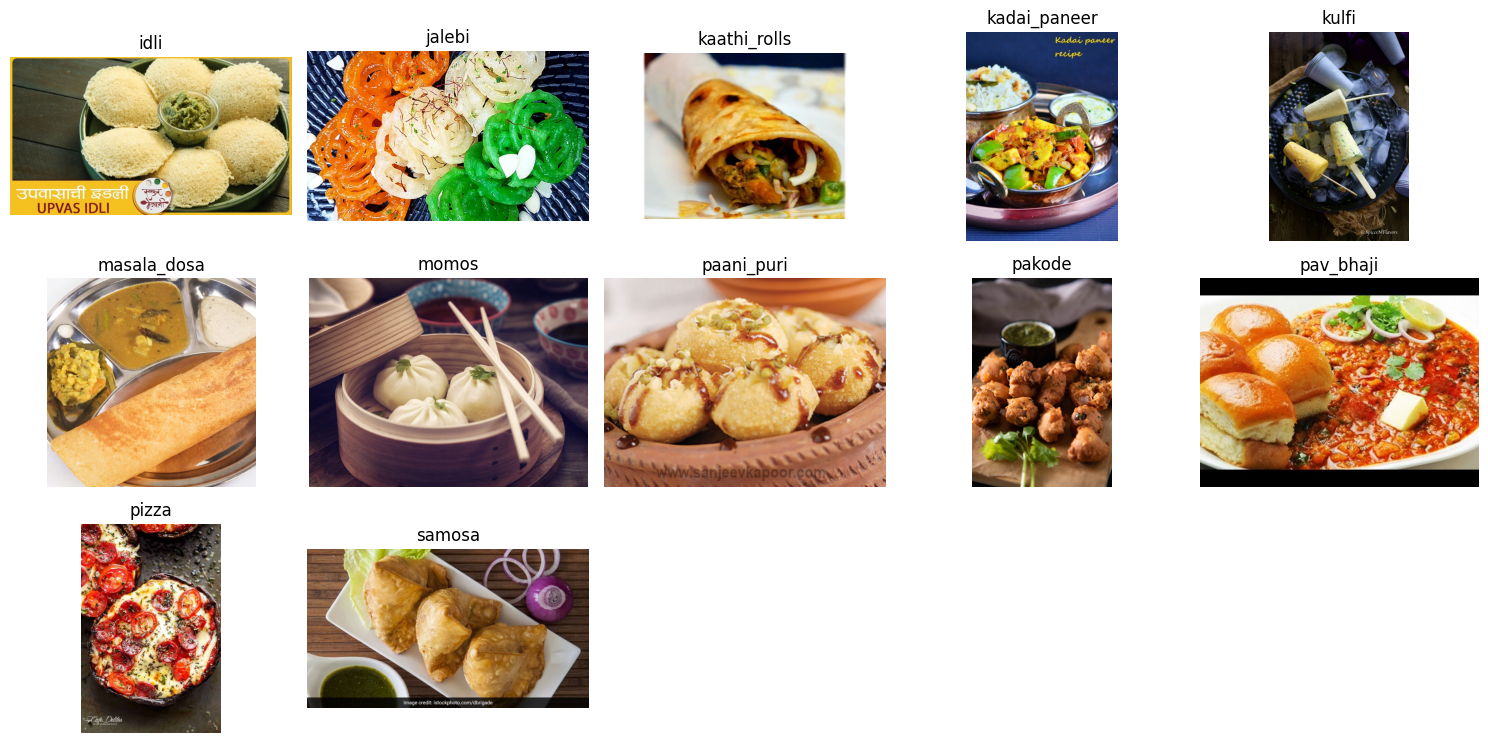

In [9]:
import random
from PIL import Image
plt.figure(figsize=(15,10))
for i, cls in enumerate(classes[8:]):
    class_path = os.path.join(dataset_path, cls)
    img_file = random.choice(os.listdir(class_path))
    img = Image.open(os.path.join(class_path, img_file))
    
    plt.subplot(4, 5, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()


## **Main Pre-trained Models:-**


### 1. ResNet (Residual Network)

**ResNet** (Residual Network) was introduced to solve the degradation problem in very deep networks by using residual (skip) connections. Popular variants include ResNet50, ResNet101, and ResNet152.

#### Advantages:

* Solves vanishing gradient problem using skip connections.
* Allows very deep architectures with improved accuracy.
* Strong generalization performance.
* Works well for transfer learning tasks.

#### Disadvantages:

* Computationally heavier than simpler models.
* Larger memory requirement.
* Training and fine-tuning can be slower compared to lightweight models.

### 2. VGG16

**VGG16** is a deep architecture consisting of 16 weight layers. It uses a simple and uniform architecture with small convolution filters (3×3).

#### Advantages:

* Simple and uniform architecture.
* Easy to implement and understand.
* Good performance for feature extraction.

#### Disadvantages:

* Very large number of parameters (~138 million).
* High memory consumption.
* Slower inference speed.
* Not efficient for mobile or embedded systems.

### 3. Inception (GoogLeNet)

**Inception** introduces the concept of parallel filter operations in the same layer, improving computational efficiency.

#### Advantages:

* More computationally efficient than VGG.
* Uses fewer parameters compared to similarly deep networks.
* Good balance between accuracy and computation.

#### Disadvantages:

* More complex architecture.
* Harder to modify and customize.
* Implementation is less straightforward.

### 4. MobileNet

**MobileNet** is designed for lightweight and mobile applications. It uses depthwise separable convolutions to reduce computation.

#### Advantages:

* Lightweight and fast.
* Low computational cost.
* Suitable for mobile and embedded devices.
* Smaller model size.

#### Disadvantages:

* Slightly lower accuracy compared to deeper architectures like ResNet.
* Less powerful for highly complex classification tasks.


## Summary

| Model     | Strength                         | Weakness         |
| --------- | -------------------------------- | ---------------- |
| ResNet    | High accuracy, deep architecture | High computation |
| VGG16     | Simple structure, good features  | Very large model |
| Inception | Efficient and accurate           | Complex design   |
| MobileNet | Lightweight and fast             | Lower accuracy   |

These pre-trained models are commonly used in transfer learning because they provide strong learned representations that can be adapted to new image classification tasks.


## **Resnet18 Architecture:-**

## **3. Train the Classification head of the model:-**

In [ ]:

import os
import copy
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tqdm import tqdm
from PIL import Image


DATA_DIR = path + "/Food Classification"   # change if needed
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 5  # early stopping patience
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])



full_dataset = datasets.ImageFolder(DATA_DIR)

class_names = full_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

# Stratified split
targets = full_dataset.targets
train_idx, val_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.2,
    stratify=targets,
    random_state=SEED
)

train_dataset = Subset(
    datasets.ImageFolder(DATA_DIR, transform=train_transforms),
    train_idx
)

val_dataset = Subset(
    datasets.ImageFolder(DATA_DIR, transform=val_transforms),
    val_idx
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))


model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)


criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.fc.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

scaler = torch.cuda.amp.GradScaler()


def train_model():
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    epochs_no_improve = 0

    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        print("-" * 30)

        #  TRAIN 
        model.train()
        running_loss = 0.0
        train_preds = []
        train_labels = []

        for images, labels in tqdm(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)
            train_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
            train_labels.extend(labels.cpu().numpy())

        train_loss = running_loss / len(train_dataset)
        train_acc = accuracy_score(train_labels, train_preds)

        #  VALIDATION 
        model.eval()
        val_preds = []
        val_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                val_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_acc = accuracy_score(val_labels, val_preds)

        print(f"Train Loss: {train_loss:.4f}")
        print(f"Train Acc : {train_acc:.4f}")
        print(f"Val Acc   : {val_acc:.4f}")

        scheduler.step(val_acc)

        #  EARLY STOPPING 
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), "best_resnet50_food.pth")
            epochs_no_improve = 0
            print("Model improved. Saved.")
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epochs")

        if epochs_no_improve >= PATIENCE:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_model_wts)
    return model, best_acc


model, best_accuracy = train_model()
print("\nBest Validation Accuracy:", best_accuracy)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))






Using device: cuda
Classes: ['burger', 'butter_naan', 'chai', 'chapati', 'chole_bhature', 'dal_makhani', 'dhokla', 'fried_rice', 'idli', 'jalebi', 'kaathi_rolls', 'kadai_paneer', 'kulfi', 'masala_dosa', 'momos', 'paani_puri', 'pakode', 'pav_bhaji', 'pizza', 'samosa']
Number of classes: 20
Train size: 5015
Validation size: 1254


C:\Users\ASUS\AppData\Local\Temp\ipykernel_41224\2725547695.py:124: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



Epoch 1/20
------------------------------


  0%|          | 0/157 [00:00<?, ?it/s]C:\Users\ASUS\AppData\Local\Temp\ipykernel_41224\2725547695.py:150: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 157/157 [01:11<00:00,  2.20it/s]


Train Loss: 2.6898
Train Acc : 0.2897
Val Acc   : 0.4530
Model improved. Saved.

Epoch 2/20
------------------------------


...

Train Loss: 0.7903
Train Acc : 0.8050
Val Acc   : 0.7799
No improvement for 3 epochs

Epoch 19/20
------------------------------


  0%|          | 0/157 [00:00<?, ?it/s]C:\Users\ASUS\AppData\Local\Temp\ipykernel_41224\2725547695.py:150: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 157/157 [01:15<00:00,  2.09it/s]


Train Loss: 0.7676
Train Acc : 0.8010
Val Acc   : 0.7735
No improvement for 4 epochs

Epoch 20/20
------------------------------


  0%|          | 0/157 [00:00<?, ?it/s]C:\Users\ASUS\AppData\Local\Temp\ipykernel_41224\2725547695.py:150: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 157/157 [01:28<00:00,  1.77it/s]


Train Loss: 0.7596
Train Acc : 0.8084
Val Acc   : 0.7855
Model improved. Saved.

Best Validation Accuracy: 0.7854864433811802

Confusion Matrix:
 [[60  0  1  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 0 42  0  9  2  5  2  2  0  0  0  2  0  0  0  0  0  1  1  0]
 [ 0  0 71  0  0  1  0  0  0  0  0  0  1  0  1  1  0  1  0  0]
 [ 1  8  6 56  0  2  0  1  0  1  3  0  0  2  1  0  0  0  0  2]
 [ 0  1  1  0 63  5  0  0  0  0  0  2  0  0  2  1  0  7  0  0]
 [ 0  0  2  2  0 54  0  2  0  0  1  3  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  0  2 46  3  2  0  0  1  1  0  0  1  0  1  0  0]
 [ 0  0  0  0  0  0  0 67  0  0  0  1  0  0  2  0  1  0  0  0]
 [ 0  0  1  3  0  2  0  1 47  0  1  1  2  3  0  1  0  0  0  0]
 [ 1  0  0  1  1  1  0  0  0 54  0  0  0  0  0  1  0  0  0  0]
 [ 0  1  1  2  0  0  0  0  0  1 50  0  0  1  1  0  1  0  0  1]
 [ 1  1  0  1  0  3  0  3  0  1  0 68  0  0  0  1  0  3  0  0]
 [ 0  0  0  3  0  3  0  2  2  0  2  0 29  3  0  2  0  1  0  0]
 [ 0  4  2  2  0  4  0  1  0  0  3 

## **4. Unfreeze few more layers of the model and train again:-**

In [ ]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import accuracy_score

# 2. LOAD BEST SAVED MODEL
model.load_state_dict(torch.load("best_resnet50_food.pth"))
model = model.to(device)
print("Loaded best previous model")

# 3. UNFREEZE LAYER3 + LAYER4 + FC
for param in model.parameters():
    param.requires_grad = False

for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

print("Unfroze layer3, layer4 and fc")

# 4. OPTIMIZER (LOW LR FOR FINE-TUNING)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

criterion = nn.CrossEntropyLoss()

# NEW AMP API (no warnings)
scaler = torch.amp.GradScaler("cuda")

# 5. FINE-TUNE TRAINING LOOP
FINE_TUNE_EPOCHS = 10
PATIENCE = 4
best_acc = 0
epochs_no_improve = 0

for epoch in range(FINE_TUNE_EPOCHS):
    print(f"\nFine-Tune Epoch {epoch+1}/{FINE_TUNE_EPOCHS}")
    print("-" * 35)

    # ---------------- TRAIN ----------------
    model.train()
    train_loss = 0
    train_preds = []
    train_labels = []

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * images.size(0)
        train_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_loss /= len(train_dataset)
    train_acc = accuracy_score(train_labels, train_preds)

    # ---------------- VALIDATION ----------------
    model.eval()
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, 1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Val Acc   : {val_acc:.4f}")

    scheduler.step(val_acc)

    # ---------------- SAVE BEST ----------------
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_resnet50_finetuned.pth")
        epochs_no_improve = 0
        print("Improved. Model saved.")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epochs")

    if epochs_no_improve >= PATIENCE:
        print("Early stopping triggered.")
        break

print("\nBest Fine-Tuned Accuracy:", best_acc)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_41224\801492046.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_resnet50_food.pth"))


Loaded best previous model
Unfroze layer3, layer4 and fc

Fine-Tune Epoch 1/10
-----------------------------------


100%|██████████| 157/157 [01:07<00:00,  2.32it/s]


Train Loss: 0.6184
Train Acc : 0.8353
Val Acc   : 0.8461
Improved. Model saved.

Fine-Tune Epoch 2/10
-----------------------------------


100%|██████████| 157/157 [01:22<00:00,  1.91it/s]


...

Train Loss: 0.1239
Train Acc : 0.9743
Val Acc   : 0.9027
No improvement for 1 epochs

Fine-Tune Epoch 9/10
-----------------------------------


100%|██████████| 157/157 [00:55<00:00,  2.83it/s]


Train Loss: 0.1031
Train Acc : 0.9777
Val Acc   : 0.9059
Improved. Model saved.

Fine-Tune Epoch 10/10
-----------------------------------


100%|██████████| 157/157 [01:20<00:00,  1.96it/s]


Train Loss: 0.0862
Train Acc : 0.9821
Val Acc   : 0.9067
Improved. Model saved.

Best Fine-Tuned Accuracy: 0.9066985645933014


In [12]:
# Load the best fine-tuned model
model.load_state_dict(torch.load("best_resnet50_finetuned.pth"))
model = model.to(device)
model.eval()
print("Loaded best fine-tuned model for evaluation")


Loaded best fine-tuned model for evaluation


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19496\3500879319.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_resnet50_finetuned.pth

## **5. Results Analysis**

In [8]:
from sklearn.metrics import classification_report

print(classification_report(val_labels, val_preds, target_names=class_names))


               precision    recall  f1-score   support

       burger       0.94      0.97      0.95        62
  butter_naan       0.85      0.85      0.85        66
         chai       0.90      0.93      0.92        76
      chapati       0.84      0.83      0.84        83
chole_bhature       0.96      0.96      0.96        82
  dal_makhani       0.88      0.94      0.91        64
       dhokla       0.98      0.83      0.90        58
   fried_rice       0.90      0.99      0.94        71
         idli       0.97      0.94      0.95        62
       jalebi       0.97      0.97      0.97        59
 kaathi_rolls       0.84      0.92      0.88        59
 kadai_paneer       0.94      0.90      0.92        82
        kulfi       0.88      0.91      0.90        47
  masala_dosa       0.95      0.92      0.93        62
        momos       0.88      0.92      0.90        64
   paani_puri       0.86      0.92      0.89        26
       pakode       0.93      0.91      0.92        56
    pav_b

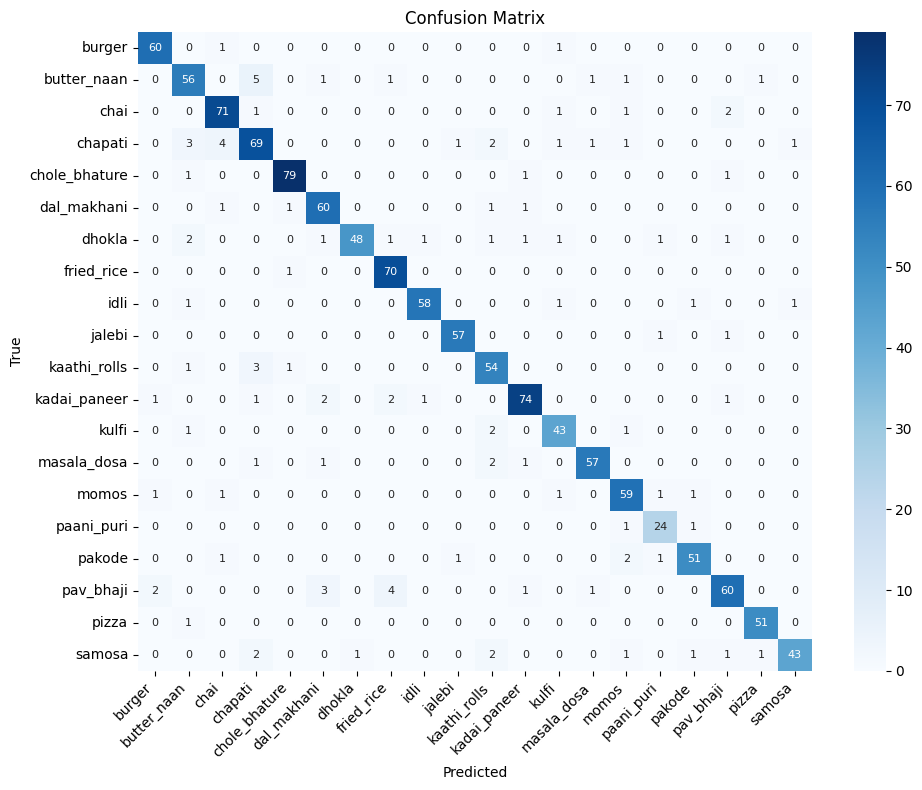

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(10,8))  # Larger for 20 classes
sns.heatmap(
    cm,
    annot=True,              # SHOW NUMBERS
    fmt="d",                 # Integer format
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 8}    # Smaller text inside boxes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
